# Diabetes Health-Indicator Risk Prediction — Exploratory Data Analysis

> **For research and educational purposes only.** This notebook explores a historical
> public dataset. Nothing here is a medical diagnosis or medical advice.

This notebook is a thin view over the reusable `ml` package. Re-run
`python -m ml.eda.run diabetes` to regenerate `reports/diabetes/`.


In [1]:
import sys, os
# Make the repository root importable when the kernel starts in notebooks/.
_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if _root not in sys.path:
    sys.path.insert(0, _root)
os.chdir(_root)  # so relative paths (reports/, data/) resolve from the repo root

import pandas as pd
pd.set_option("display.max_columns", 60)

from ml.data.loaders import load_diabetes
from ml.eda import profile

X, y, spec = load_diabetes()
print(spec.notes)


Target: 'Diabetes_binary' where 1 = prediabetes OR diabetes, 0 = neither. Derived from the CDC BRFSS survey (self-reported). Features are health indicators, not laboratory measurements: this module estimates a RISK ASSOCIATION, not a diagnosis. Full imbalanced release (~14% positive), n=253,680. Ordinal survey codes (GenHlth, Age, Education, Income) are modelled as numeric.


## 1. Dataset overview

In [2]:
profile.dataset_overview(X, y, spec)

{'disease': 'diabetes',
 'n_rows': 253680,
 'n_features': 21,
 'n_numeric': 7,
 'n_categorical': 0,
 'n_binary': 14,
 'target': 'diabetes_or_prediabetes',
 'target_positive_meaning': "Target: 'Diabetes_binary' where 1 = prediabetes OR diabetes, 0 = neither",
 'total_missing_cells': 0,
 'rows_with_any_missing': 0,
 'duplicate_rows': 25772,
 'memory_mb': np.float64(42.618)}

## 2. Target distribution

In [3]:
display(profile.target_distribution(y))
print("class-imbalance ratio (majority / minority):", profile.class_imbalance_ratio(y))


,class,count,proportion
0,0,218334,0.8607
1,1,35346,0.1393


class-imbalance ratio (majority / minority): 6.18


## 3. Missing values

In [4]:
profile.missing_value_table(X)

,column,dtype,n_missing,pct_missing,n_unique
0,BMI,int64,0,0.0,84
1,MentHlth,int64,0,0.0,31
2,PhysHlth,int64,0,0.0,31
3,GenHlth,int64,0,0.0,5
4,Age,int64,0,0.0,13
5,Education,int64,0,0.0,6
6,Income,int64,0,0.0,8
7,HighBP,int64,0,0.0,2
8,HighChol,int64,0,0.0,2
9,CholCheck,int64,0,0.0,2


## 4. Numeric feature summary

In [5]:
profile.numeric_summary(X, spec)

,count,mean,std,min,25%,50%,75%,max,missing,skew
BMI,253680.0,28.382,6.609,12.0,24.0,27.0,31.0,98.0,0,2.122
MentHlth,253680.0,3.185,7.413,0.0,0.0,0.0,2.0,30.0,0,2.721
PhysHlth,253680.0,4.242,8.718,0.0,0.0,0.0,3.0,30.0,0,2.207
GenHlth,253680.0,2.511,1.068,1.0,2.0,2.0,3.0,5.0,0,0.423
Age,253680.0,8.032,3.054,1.0,6.0,8.0,10.0,13.0,0,-0.360
Education,253680.0,5.050,0.986,1.0,4.0,5.0,6.0,6.0,0,-0.777
Income,253680.0,6.054,2.071,1.0,5.0,7.0,8.0,8.0,0,-0.891


## 5. Outlier scan (IQR fences — diagnostic only, nothing removed)

In [6]:
profile.outlier_scan(X, spec)

,column,q1,q3,iqr_lower_fence,iqr_upper_fence,n_outliers,pct_outliers,min,max
0,BMI,24.0,31.0,13.5,41.5,9847,3.88,12.0,98.0
1,MentHlth,0.0,2.0,-3.0,5.0,36208,14.27,0.0,30.0
2,PhysHlth,0.0,3.0,-4.5,7.5,40949,16.14,0.0,30.0
3,GenHlth,2.0,3.0,0.5,4.5,12081,4.76,1.0,5.0
4,Age,6.0,10.0,0.0,16.0,0,0.00,1.0,13.0
5,Education,4.0,6.0,1.0,9.0,0,0.00,1.0,6.0
6,Income,5.0,8.0,0.5,12.5,0,0.00,1.0,8.0


## 6. Numeric feature / target association (descriptive)

In [7]:
profile.target_feature_association(X, y, spec)

,feature,corr_with_target
0,GenHlth,0.294
1,BMI,0.217
2,Age,0.177
3,PhysHlth,0.171
4,Income,-0.164
5,Education,-0.124
6,MentHlth,0.069


## 7. Categorical / binary breakdown

In [8]:
cs = profile.categorical_summary(X, spec)
for name, table in cs.items():
    print(f"--- {name} ---")
    display(table)


--- HighBP ---


,value,count,proportion
0,0,144851,0.571
1,1,108829,0.429


--- HighChol ---


,value,count,proportion
0,0,146089,0.5759
1,1,107591,0.4241


--- CholCheck ---


...

,value,count,proportion
0,0,232326,0.9158
1,1,21354,0.0842


--- DiffWalk ---


,value,count,proportion
0,0,211005,0.8318
1,1,42675,0.1682


--- Sex ---


,value,count,proportion
0,0,141974,0.5597
1,1,111706,0.4403


## 8. Figures

Generated into `reports/diabetes/figures/`.

categorical_positive_rate.png


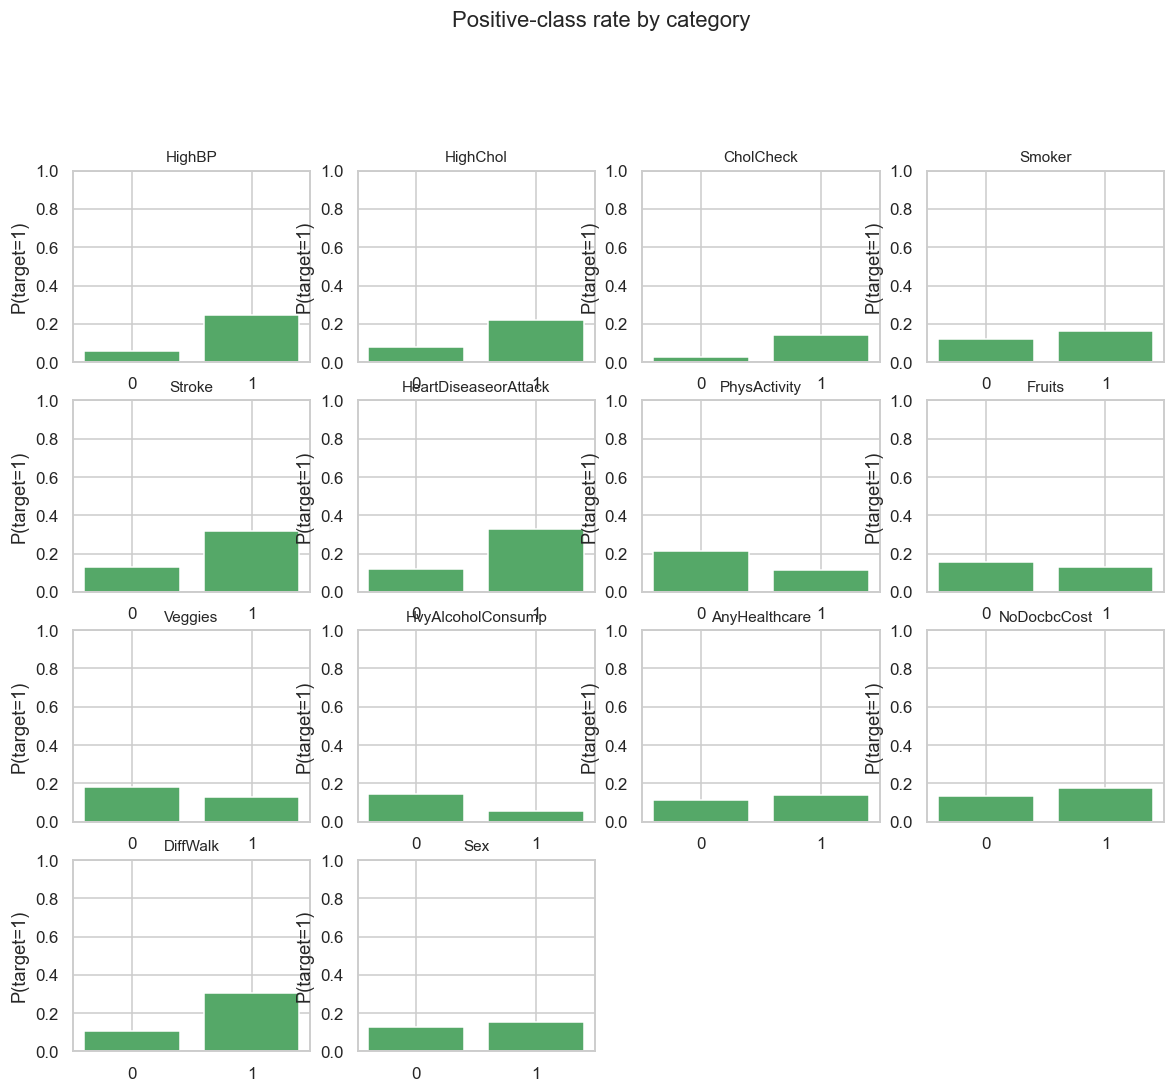

correlation_heatmap.png


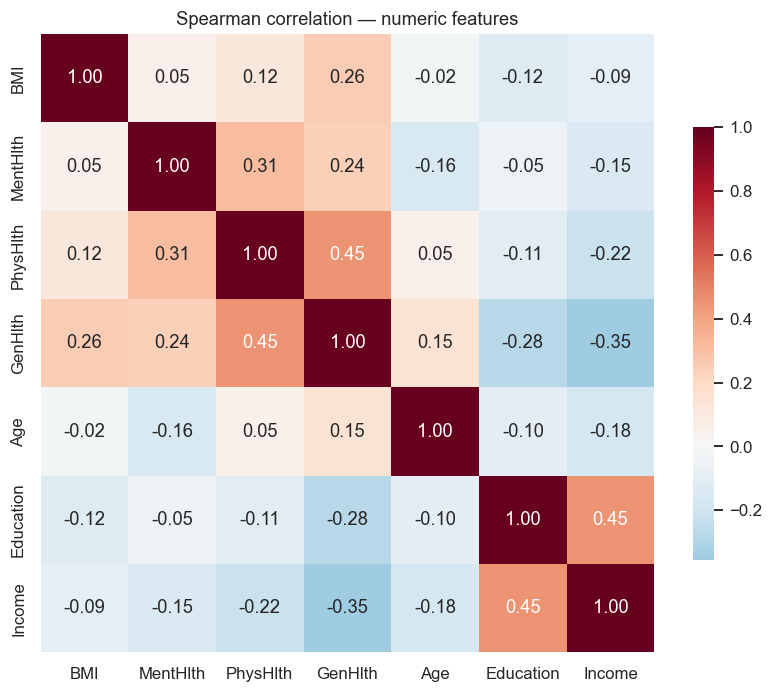

missingness.png


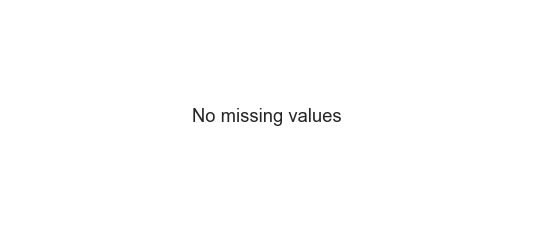

numeric_boxplots_by_target.png


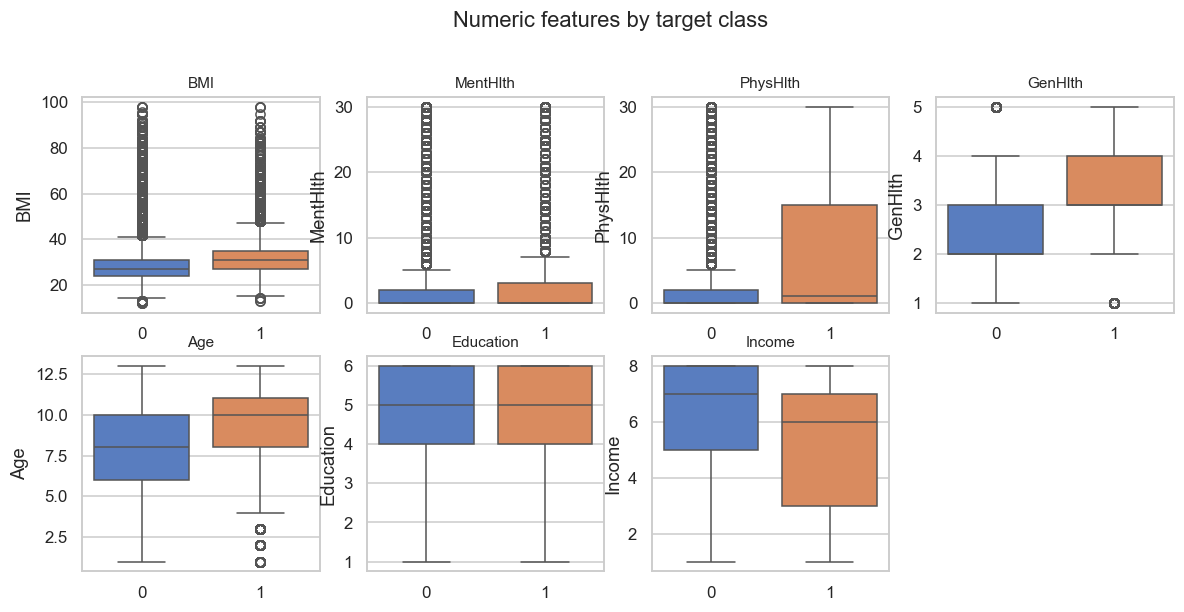

numeric_histograms.png


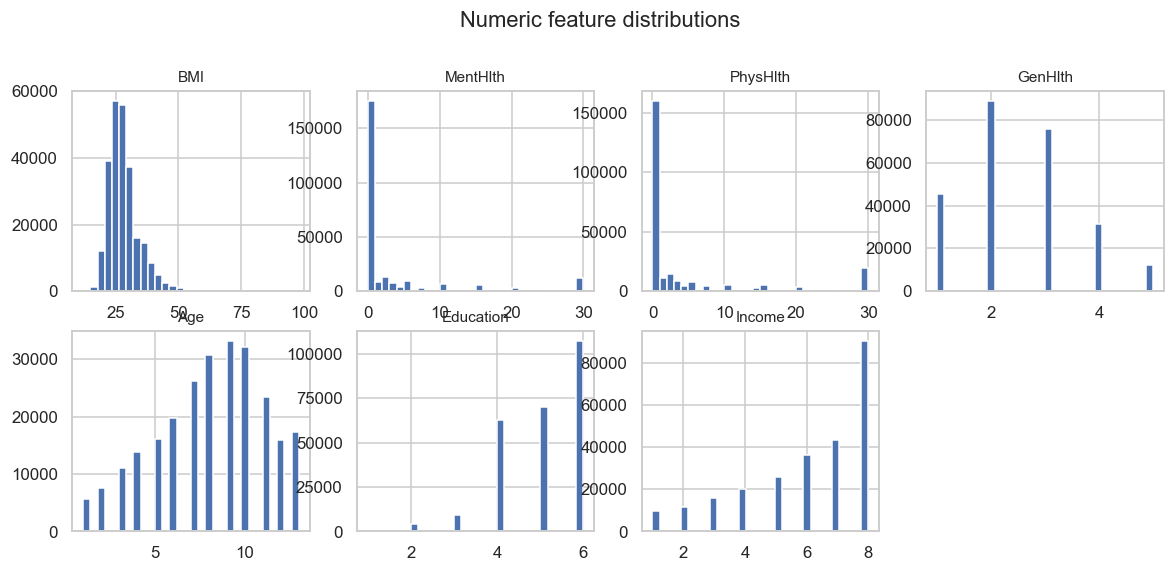

target_distribution.png


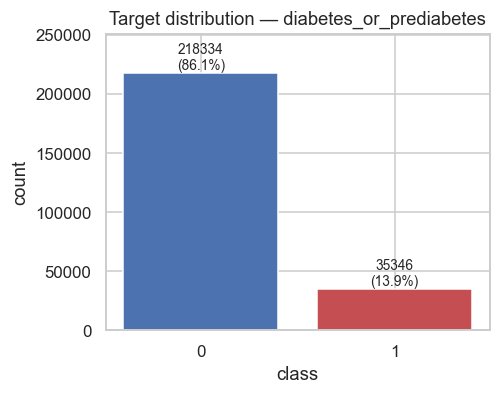

In [9]:
from pathlib import Path
from IPython.display import Image, display
from ml.eda.run import run_eda

run_eda("diabetes")
fig_dir = Path("reports") / "diabetes" / "figures"
for png in sorted(fig_dir.glob("*.png")):
    print(png.name)
    display(Image(filename=str(png)))


## 9. Written summaries

- Target definition + feature dictionary: [`reports/diabetes/TARGET.md`](../reports/diabetes/TARGET.md)
- EDA summary: [`reports/diabetes/EDA.md`](../reports/diabetes/EDA.md)
